### KITTI-360 LiDAR Projection

In this notebook, LiDAR point clouds are projected onto RGB images using camera calibration parameters. The pipeline includes coordinate transformation, image projection, and depth map generation.

In [ ]:
import numpy as np
import cv2
import open3d as o3d
import matplotlib.pyplot as plt

### Load and Display the RGB Image

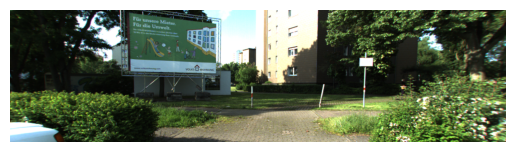

In [12]:
image = cv2.imread("0000000000.png")
image = cv2.cvtColor(image ,cv2.COLOR_BGR2RGB)
plt.axis("off")
plt.imshow(image)

### Load the LiDAR Point Cloud

In [13]:
lidar_data = np.fromfile("0000000000.bin" , dtype = np.float32).reshape(-1,4)
xyz = lidar_data[: , :3]

# pcd = o3d.geometry.PointCloud()
# pcd.points = o3d.utility.Vector3dVector(xyz)
# o3d.visualization.draw_geometries_with_editing([pcd])

### Load the Extrinsic Calibration Matrix

In [26]:
T_cam_to_velo = np.loadtxt("calibration/calib_cam_to_velo.txt")
T_cam_to_velo = T_cam_to_velo.reshape(3, 4)

# Convert to homogeneous transformation matrix
T_cam_to_velo_4x4 = np.eye(4)
T_cam_to_velo_4x4[:3, :] = T_cam_to_velo

# Camera → LiDAR  ==>  LiDAR → Camera
T_velo_to_cam = np.linalg.inv(T_cam_to_velo_4x4)

print(T_velo_to_cam)

[[ 0.04307104 -0.99900437 -0.01162549  0.26234696]
 [-0.08829286  0.00778461 -0.99606414 -0.10763414]
 [ 0.99516293  0.04392797 -0.08786967 -0.82920525]
 [ 0.          0.          0.          1.        ]]


### Transform LiDAR Points to the Camera Coordinate System

In [ ]:
# Convert to homogeneous coordinates
ones = np.ones((xyz.shape[0], 1))
xyz_h = np.hstack([xyz, ones])

# LiDAR → Camera transformation
points_cam = (T_velo_to_cam @ xyz_h.T).T

# Keep only points in front of the camera
Zc = points_cam[:, 2]
mask = Zc > 0
points_cam = points_cam[mask]

### Rectify and Project LiDAR Points onto the Image Plane

In [32]:
# Rectification matrix
R_rect_00 = np.array([
    [0.999974, -0.007141, -0.000089],
    [0.007141,  0.999969, -0.003247],
    [0.000112,  0.003247,  0.999995]
])

points_rect = (R_rect_00 @ points_cam[:, :3].T).T

# Rectified intrinsic matrix
fx = 552.554261
cx = 682.049453
fy = 552.554261
cy = 238.769549
 
K = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
])

# Projection
pixels = (K @ points_rect[:, :3].T).T

u = pixels[:,0] / pixels[:,2]
v = pixels[:,1] / pixels[:,2]

### Filter Valid Projected Points

In [33]:
H, W = image.shape[:2]

# Keep points inside image boundaries
mask = (
    (u >= 0) & (u < W) &
    (v >= 0) & (v < H)
)

u = u[mask].astype(int)
v = v[mask].astype(int)

# Depth in rectified camera coordinate system
depth = points_rect[mask, 2]

### Generate the Sparse LiDAR Depth Map

In [34]:
depth_map = np.zeros((H,W), dtype=np.float32)

for x,y,d in zip(u,v,depth):
    if depth_map[y,x] == 0:
        depth_map[y,x] = d
    else:
        depth_map[y,x] = min(depth_map[y,x], d)

### Visualize the RGB Image and LiDAR Depth Map

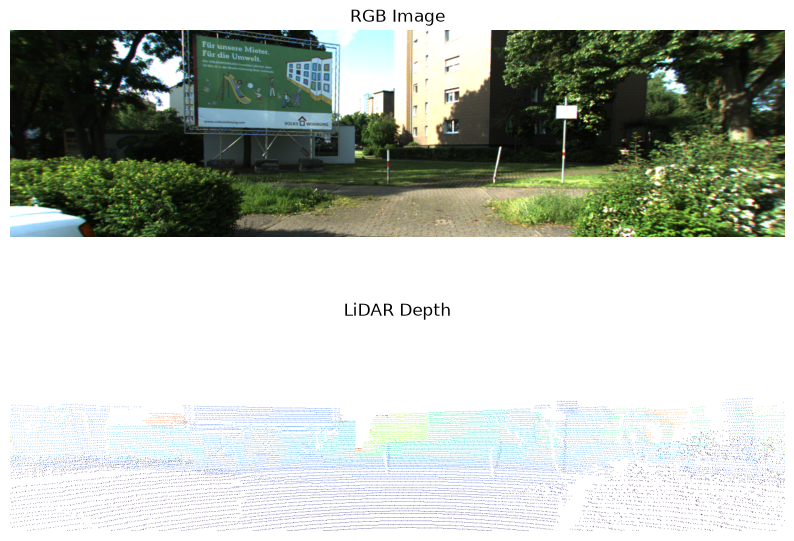

In [35]:
depth_show = depth_map.copy()
depth_show[depth_show == 0] = np.nan

cmap = plt.cm.turbo.copy()
cmap.set_bad(color="white")

plt.figure(figsize=(10,7))

# RGB
plt.subplot(2,1,1)
plt.imshow(image)
plt.title("RGB Image")
plt.axis("off")

# Depth
plt.subplot(2,1,2)
plt.imshow(depth_show, cmap=cmap)
plt.title("LiDAR Depth")
# plt.colorbar(label="Depth (m)")
plt.axis("off")
plt.show()

### Overlay LiDAR Depth on the RGB Image

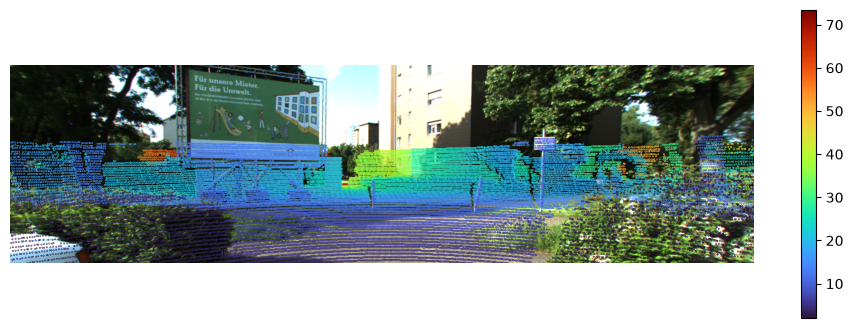

In [36]:
#RGB-Depth
plt.figure(figsize=(12,4))
plt.imshow(image)

plt.scatter(u,v,s=0.1,c=depth,cmap="turbo")

plt.colorbar()
plt.axis("off")
plt.show()